# 🌾 Ghana Crop Price Prediction
### Complete Per-Commodity Machine Learning Pipeline

**Dataset:** WFP Food Prices — Ghana (2006–2023)  
**Target:** Predict `cedi_price` per kg for each of the 26 commodities  
**Model:** `HistGradientBoostingRegressor` (scikit-learn's fast gradient boosting)

---
### Notebook Structure
| # | Section |
|---|---|
| 1 | Setup & Imports |
| 2 | Load & Inspect Data |
| 3 | Data Cleaning |
| 4 | Exploratory Data Analysis |
| 5 | Feature Engineering |
| 6 | Per-Commodity Model Training & Evaluation |
| 7 | Results Summary & Comparison |
| 8 | Visualisations |
| 9 | Export Predictions |


---
## 1. Setup & Imports

In [1]:
# Core libraries
import warnings
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import FormatStrFormatter

# Scikit-learn: preprocessing, modelling, evaluation
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings('ignore')

# ── Display settings ──────────────────────────────────────────────────────────
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.grid':        True,
    'grid.linestyle':   '--',
    'grid.alpha':       0.4,
    'font.family':      'sans-serif',
})

# ── Colour palette (Ghana flag inspired) ─────────────────────────────────────
PALETTE = {
    'green':        '#1b5e20',
    'mid_green':    '#2d6a4f',
    'light_green':  '#52b788',
    'gold':         '#f4a261',
    'red':          '#c62828',
    'blue':         '#1565c0',
    'gray':         '#6c757d',
}

print('✅ Imports complete')

✅ Imports complete


In [13]:
# ── Configuration — edit these paths/settings as needed ──────────────────────

DATA_PATH   = 'original_dataset/wfp_food_prices_gha.csv'   # path to your CSV file
OUTPUT_DIR  = 'images/'                          # where to save outputs
N_CV_FOLDS  = 5                            # walk-forward CV folds
TRAIN_RATIO = 0.80                         # 80% train / 20% hold-out
MIN_ROWS    = 50                           # skip commodities with fewer rows than this
RANDOM_SEED = 42

# Ghana farming seasons
MAJOR_HARVEST_MONTHS = [7, 8]        # July–August
MINOR_HARVEST_MONTHS = [11, 12]      # November–December
PLANTING_MONTHS      = [4, 5, 8, 9]  # April–May, August–September

# Coordinates of Ghana's three largest markets (used for distance features)
MAJOR_MARKETS = {
    'accra':  (5.6037,  -0.1870),
    'kumasi': (6.6885,  -1.6244),
    'tamale': (9.4008,  -0.8393),
}

print('✅ Configuration set')

✅ Configuration set


---
## 2. Load & Inspect Data

In [4]:
# Load the CSV
df_raw = pd.read_csv(DATA_PATH, low_memory=False)

# Rename columns to canonical pipeline names
# (the WFP CSV uses slightly different names from what the pipeline expects)
df_raw = df_raw.rename(columns={
    'unit':      'unit_kg',    # e.g. '91 KG', 'KG', 'Bunch'
    'priceflag': 'price_flag', # 'actual', 'aggregate', etc.
    'pricetype': 'price_type', # 'Wholesale', 'Retail'
    'usdprice':  'price_usd',  # price in US dollars
})

print(f'Rows: {len(df_raw):,}   Columns: {df_raw.shape[1]}')
df_raw.head()

Rows: 39,038   Columns: 16


,date,region,city,market_sold_at,market_id,latitude,longitude,commodity,category,commodity_id,unit_kg,price_flag,price_type,currency,price,price_usd
0,15/01/2006,ASHANTI,Kumasi,KMA,215,6.6800,-1.6200,Cassava,cereals and tubers,68,91 KG,actual,Wholesale,GHS,10.3100,11.2100
1,15/01/2006,ASHANTI,Kumasi,KMA,215,6.6800,-1.6200,Maize,cereals and tubers,51,100 KG,actual,Wholesale,GHS,25.4000,27.6100
2,15/01/2006,ASHANTI,Kumasi,KMA,215,6.6800,-1.6200,Rice (local),cereals and tubers,71,50 KG,actual,Wholesale,GHS,33.0600,35.9300
3,15/01/2006,ASHANTI,Kumasi,KMA,215,6.6800,-1.6200,Sorghum,cereals and tubers,65,109 KG,actual,Wholesale,GHS,38.2500,41.5800
4,15/01/2006,ASHANTI,Kumasi,KMA,215,6.6800,-1.6200,Yam,cereals and tubers,99,250 KG,actual,Wholesale,GHS,63.3800,68.8900


In [5]:
# Data types and null counts
info = pd.DataFrame({
    'dtype':    df_raw.dtypes,
    'nulls':    df_raw.isnull().sum(),
    'null_%':   (df_raw.isnull().mean() * 100).round(2),
    'nunique':  df_raw.nunique(),
})
print(info.to_string())

                  dtype  nulls  null_%  nunique
date             object      0  0.0000      211
region           object      0  0.0000       10
city             object      0  0.0000       44
market_sold_at   object      0  0.0000       42
market_id         int64      0  0.0000       44
latitude        float64      0  0.0000       41
longitude       float64      0  0.0000       40
commodity        object      0  0.0000       26
category         object      0  0.0000        4
commodity_id      int64      0  0.0000       26
unit_kg          object      0  0.0000       18
price_flag       object      0  0.0000        3
price_type       object      0  0.0000        2
currency         object      0  0.0000        1
price           float64      0  0.0000     9501
price_usd       float64      0  0.0000     8917


In [6]:
# Summary statistics for numeric columns
df_raw.describe()

,market_id,latitude,longitude,commodity_id,price,price_usd
count,39038.0000,39038.0000,39038.0000,39038.0000,39038.0000,39038.0000
mean,447.1767,7.2581,-1.0905,220.4062,132.8255,27.2651
std,618.0645,1.8083,0.8584,246.9435,224.3247,35.6216
min,209.0000,4.9300,-2.8800,51.0000,0.3200,0.0590
25%,213.0000,5.6200,-1.7000,68.0000,5.5600,0.8200
50%,217.0000,7.1500,-1.2400,98.0000,37.4050,13.0200
75%,221.0000,8.0600,-0.2200,248.0000,180.0000,43.6000
max,2802.0000,11.0500,0.5200,792.0000,4718.9500,500.9800


In [8]:
# All 26 commodities and their observation counts
commodity_counts = df_raw['commodity'].value_counts()
print(f'Total unique crops: {len(commodity_counts)}')
print()
print(commodity_counts.to_string())

Total unique crops: 26

commodity
Maize                     3494
Yam                       3105
Rice (local)              3083
Cassava                   2997
Plantains (apentu)        2964
Rice (imported)           2570
Millet                    2332
Sorghum                   2286
Maize (yellow)            1286
Plantains (apem)          1264
Gari                      1219
Yam (puna)                1166
Tomatoes (navrongo)       1096
Eggplants                 1068
Tomatoes (local)          1030
Peppers (fresh)           1023
Soybeans                  1018
Onions                    1014
Meat (chicken)             984
Fish (mackerel, fresh)     956
Peppers (dried)            819
Cowpeas                    641
Eggs                       480
Meat (chicken, local)      456
Rice (paddy)               355
Cowpeas (white)            332


---
## 3. Data Cleaning

In [10]:
def clean_data(df: pd.DataFrame) -> pd.DataFrame:
    """
    Clean the raw WFP dataset:
      1. Parse dates (DD/MM/YYYY format)
      2. Extract numeric kg value from the unit column
      3. Compute price_per_kg_usd (our target variable)
      4. Remove rows with non-positive prices
      5. Remove per-commodity price outliers (1st–99th percentile)
      6. Sort chronologically
    """
    df = df.copy()

    # Parse dates — WFP uses DD/MM/YYYY format
    df['date'] = pd.to_datetime(df['date'], dayfirst=True, errors='coerce')
    before = len(df)
    df = df.dropna(subset=['date', 'price_usd', 'commodity'])
    print(f'  Dropped {before - len(df):,} rows with missing date/price/commodity')

    # Extract numeric kg from unit strings like '91 KG', '100 KG', 'KG', 'Bunch'
    # Non-numeric units (Bunch, Tubers) fall back to 1 (treated as 1 unit)
    df['unit_kg_num'] = (
        df['unit_kg'].astype(str)
        .str.extract(r'(\d+\.?\d*)')
        .squeeze()
        .astype(float)
        .fillna(1.0)
    )
    df['unit_kg_num'] = df['unit_kg_num'].replace(0, 1.0)  # avoid division by zero

    # TARGET: price per kg in USD
    df['price_per_kg_usd'] = df['price_usd'] / df['unit_kg_num']
    df = df[df['price_per_kg_usd'] > 0]

    # Remove outliers per commodity (keeps 1st–99th percentile)
    q_low  = df.groupby('commodity')['price_per_kg_usd'].transform(lambda x: x.quantile(0.01))
    q_high = df.groupby('commodity')['price_per_kg_usd'].transform(lambda x: x.quantile(0.99))
    before = len(df)
    df = df[(df['price_per_kg_usd'] >= q_low) & (df['price_per_kg_usd'] <= q_high)]
    print(f'  Removed {before - len(df):,} price outliers (per-commodity 1st–99th pct)')

    # Sort chronologically — essential for lag features and time-series CV
    df = df.sort_values('date').reset_index(drop=True)
    print(f'  Clean dataset: {len(df):,} rows')
    print(f'  Date range:    {df["date"].min().date()} → {df["date"].max().date()}')
    return df


print('Cleaning data...')
df = clean_data(df_raw)
print('\nSample of cleaned data:')
df[['date', 'commodity', 'region', 'city', 'unit_kg', 'unit_kg_num',
    'price_usd', 'price_per_kg_usd', 'price_type']].head(8)

Cleaning data...
  Dropped 0 rows with missing date/price/commodity
  Removed 787 price outliers (per-commodity 1st–99th pct)
  Clean dataset: 38,251 rows
  Date range:    2006-01-15 → 2023-07-15

Sample of cleaned data:


,date,commodity,region,city,unit_kg,unit_kg_num,price_usd,price_per_kg_usd,price_type
0,2006-01-15,Cassava,ASHANTI,Kumasi,91 KG,91.0000,11.2100,0.1232,Wholesale
1,2006-01-15,Yam,UPPER WEST,Wa,250 KG,250.0000,53.2600,0.2130,Wholesale
2,2006-01-15,Sorghum,UPPER WEST,Wa,109 KG,109.0000,33.8400,0.3105,Wholesale
3,2006-01-15,Rice (local),UPPER WEST,Wa,50 KG,50.0000,28.3400,0.5668,Wholesale
4,2006-01-15,Millet,UPPER WEST,Wa,93 KG,93.0000,33.5300,0.3605,Wholesale
5,2006-01-15,Maize,UPPER WEST,Wa,100 KG,100.0000,23.2600,0.2326,Wholesale
6,2006-01-15,Yam,UPPER EAST,Bolga,250 KG,250.0000,43.4800,0.1739,Wholesale
7,2006-01-15,Sorghum,UPPER EAST,Bolga,109 KG,109.0000,27.1700,0.2493,Wholesale


---
## 4. Exploratory Data Analysis

In [11]:
# ── Price distribution per commodity ─────────────────────────────────────────
commodity_stats = (
    df.groupby('commodity')['price_per_kg_usd']
    .agg(['count', 'mean', 'median', 'std', 'min', 'max'])
    .round(4)
    .sort_values('mean', ascending=False)
)
commodity_stats.columns = ['Count', 'Mean USD/kg', 'Median USD/kg', 'Std', 'Min', 'Max']
print('Price statistics per commodity (sorted by mean price):')
commodity_stats

Price statistics per commodity (sorted by mean price):


,Count,Mean USD/kg,Median USD/kg,Std,Min,Max
commodity,,,,,,
Plantains (apem),1238,6.9764,1.3400,11.7650,0.1600,63.6600
Plantains (apentu),2911,4.5001,3.7200,3.9205,0.1500,25.6900
"Meat (chicken, local)",446,3.8219,3.8005,2.1740,0.5330,10.2330
Meat (chicken),967,2.4311,1.7700,2.0630,0.2200,10.1450
Eggs,471,1.9375,1.8407,1.1410,0.0937,5.5970
"Fish (mackerel, fresh)",937,1.6678,1.4000,1.0970,0.3000,6.7400
Peppers (fresh),1002,1.4181,0.8820,1.3863,0.1200,6.3630
Peppers (dried),801,1.1722,0.8100,1.1214,0.0600,5.7800
Rice (imported),2519,1.0611,1.0100,0.3119,0.3706,1.8200


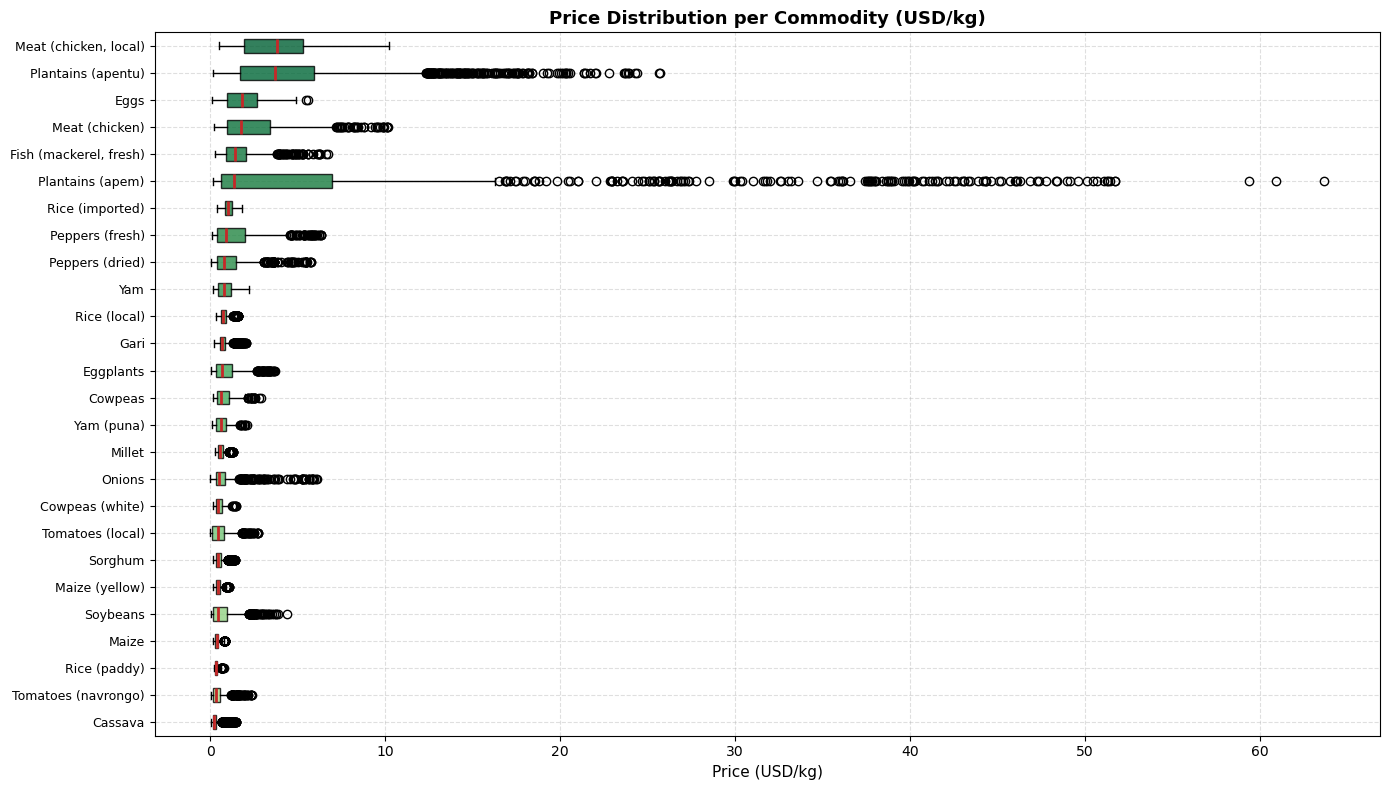

In [14]:
# ── Box plot: price distribution per commodity ────────────────────────────────
order = commodity_stats.sort_values('Median USD/kg').index.tolist()

fig, ax = plt.subplots(figsize=(14, 8))
data_to_plot = [df[df['commodity'] == c]['price_per_kg_usd'].values for c in order]
bp = ax.boxplot(data_to_plot, vert=False, patch_artist=True,
                medianprops={'color': PALETTE['red'], 'lw': 2})

colors = plt.cm.YlGn(np.linspace(0.35, 0.9, len(order)))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)

ax.set_yticks(range(1, len(order) + 1))
ax.set_yticklabels(order, fontsize=9)
ax.set_xlabel('Price (USD/kg)', fontsize=11)
ax.set_title('Price Distribution per Commodity (USD/kg)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/eda_price_distribution.png', dpi=130, bbox_inches='tight')
plt.show()

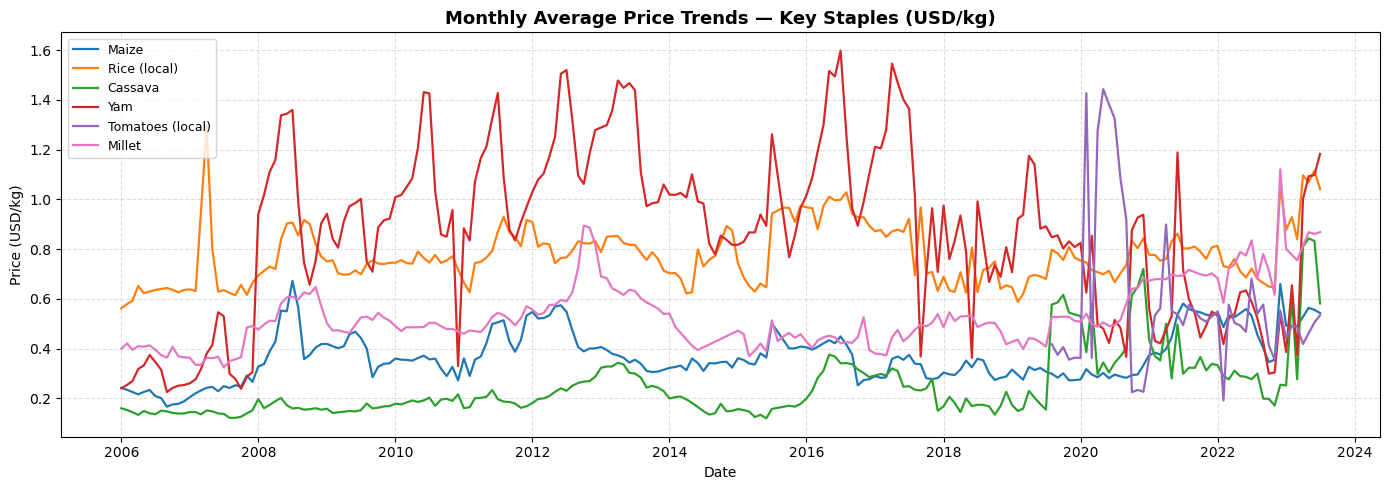

In [15]:
# ── Monthly average price trends for key staples ─────────────────────────────
STAPLES = ['Maize', 'Rice (local)', 'Cassava', 'Yam', 'Tomatoes (local)', 'Millet']

df_staples = df[df['commodity'].isin(STAPLES)].copy()
df_staples['year_month'] = df_staples['date'].dt.to_period('M').dt.to_timestamp()

monthly_avg = (
    df_staples.groupby(['year_month', 'commodity'])['price_per_kg_usd']
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(14, 5))
colors_staples = plt.cm.tab10(np.linspace(0, 0.6, len(STAPLES)))
for commodity, color in zip(STAPLES, colors_staples):
    subset = monthly_avg[monthly_avg['commodity'] == commodity]
    ax.plot(subset['year_month'], subset['price_per_kg_usd'],
            label=commodity, lw=1.6, color=color)

ax.set_title('Monthly Average Price Trends — Key Staples (USD/kg)', fontsize=13, fontweight='bold')
ax.set_ylabel('Price (USD/kg)')
ax.set_xlabel('Date')
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/eda_price_trends.png', dpi=130, bbox_inches='tight')
plt.show()

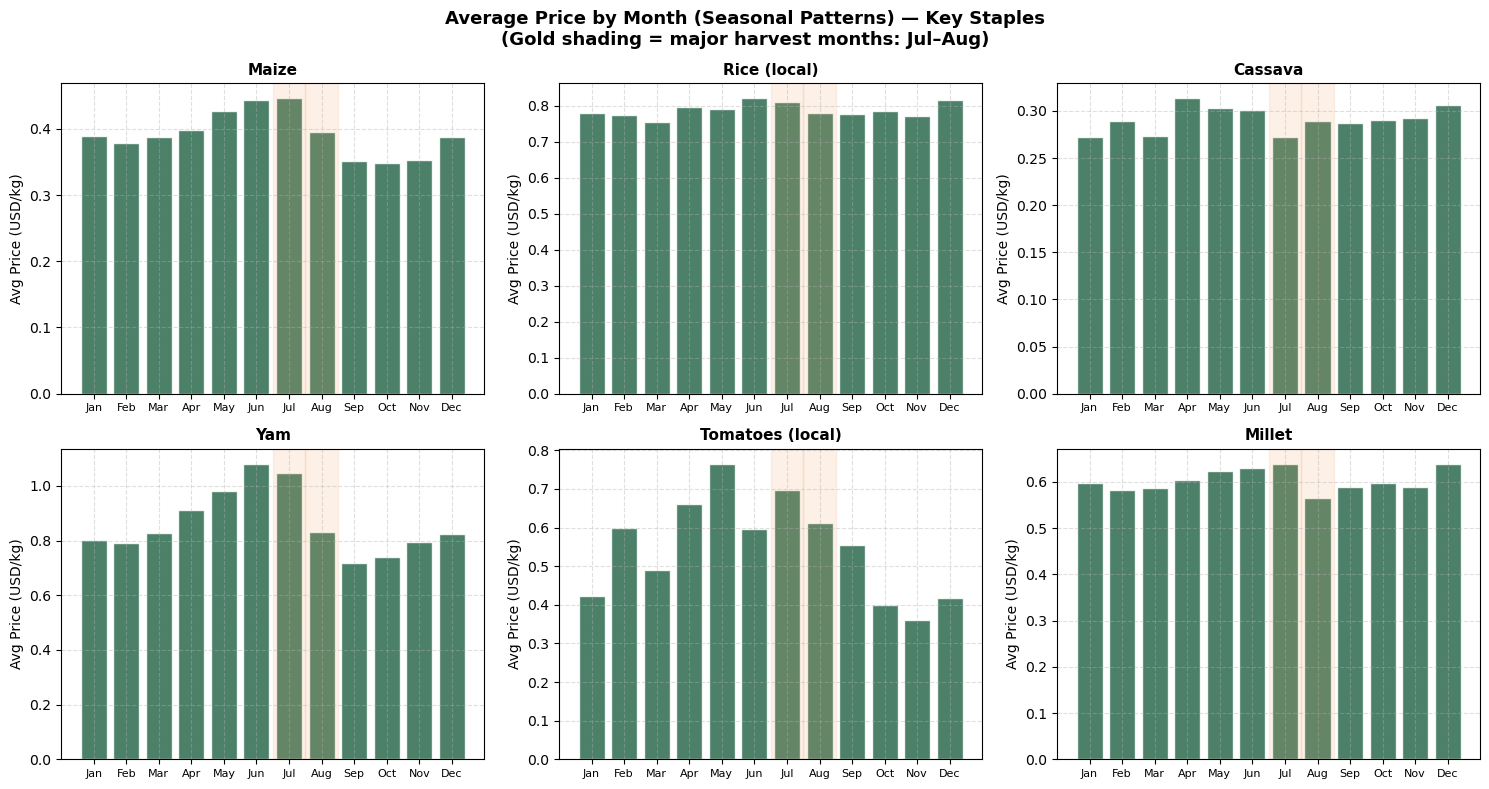

In [16]:
# ── Seasonal price patterns (average price by month across all years) ─────────
MONTH_NAMES = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

df['month_num'] = df['date'].dt.month
seasonal = df.groupby(['commodity', 'month_num'])['price_per_kg_usd'].mean().reset_index()

# Show for staples only
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, commodity in enumerate(STAPLES):
    subset = seasonal[seasonal['commodity'] == commodity]
    axes[i].bar(subset['month_num'], subset['price_per_kg_usd'],
                color=PALETTE['mid_green'], alpha=0.85, edgecolor='white')
    axes[i].set_title(commodity, fontweight='bold', fontsize=11)
    axes[i].set_xticks(range(1, 13))
    axes[i].set_xticklabels(MONTH_NAMES, fontsize=8)
    axes[i].set_ylabel('Avg Price (USD/kg)')
    # Shade harvest months
    for m in MAJOR_HARVEST_MONTHS:
        axes[i].axvspan(m - 0.5, m + 0.5, alpha=0.15, color=PALETTE['gold'], label='Major harvest' if m == MAJOR_HARVEST_MONTHS[0] else '')

fig.suptitle('Average Price by Month (Seasonal Patterns) — Key Staples\n'
             '(Gold shading = major harvest months: Jul–Aug)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/eda_seasonal_patterns.png', dpi=130, bbox_inches='tight')
plt.show()

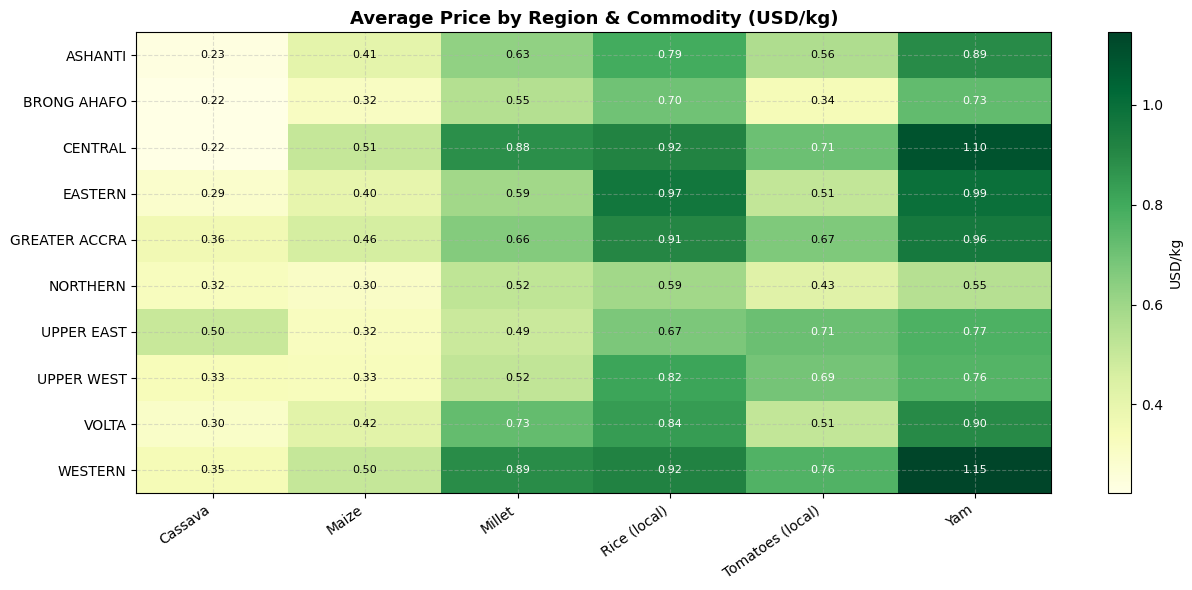

In [17]:
# ── Regional price heatmap ────────────────────────────────────────────────────
regional_pivot = (
    df[df['commodity'].isin(STAPLES)]
    .groupby(['region', 'commodity'])['price_per_kg_usd']
    .mean()
    .unstack('commodity')
    .round(3)
)

fig, ax = plt.subplots(figsize=(13, 6))
im = ax.imshow(regional_pivot.values, cmap='YlGn', aspect='auto')
ax.set_xticks(range(len(regional_pivot.columns)))
ax.set_xticklabels(regional_pivot.columns, rotation=35, ha='right', fontsize=10)
ax.set_yticks(range(len(regional_pivot.index)))
ax.set_yticklabels(regional_pivot.index, fontsize=10)
ax.set_title('Average Price by Region & Commodity (USD/kg)', fontsize=13, fontweight='bold')
plt.colorbar(im, ax=ax, label='USD/kg')

# Annotate cells
for i in range(len(regional_pivot.index)):
    for j in range(len(regional_pivot.columns)):
        val = regional_pivot.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=8,
                    color='white' if val > regional_pivot.values.max() * 0.6 else 'black')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/eda_regional_heatmap.png', dpi=130, bbox_inches='tight')
plt.show()

---
## 5. Feature Engineering

In [18]:
# ── Helper functions ──────────────────────────────────────────────────────────

def haversine_km(lat1, lon1, lat2, lon2):
    """
    Calculate straight-line distance in km between two geographic points.
    Accounts for Earth's curvature using the haversine formula.
    Vectorised — works on pandas Series or scalar values.

    Parameters
    ----------
    lat1, lon1 : float or Series — latitude/longitude of the first point (decimal degrees)
    lat2, lon2 : float or Series — latitude/longitude of the second point (decimal degrees)

    Returns
    -------
    Distance in kilometres
    """
    R = 6371.0  # Earth's mean radius in km
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlam = np.radians(lon2 - lon1)
    a = np.sin(dphi / 2)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlam / 2)**2
    return 2 * R * np.arcsin(np.sqrt(a))


def add_target_encoding(df, col, target, smoothing=10):
    """
    Smooth target encoding for a categorical column.
    Replaces each category with a weighted blend of its own mean and the global mean.
    Rare categories are pulled toward the global mean to avoid overfitting.

    Formula: encoded = (count * cat_mean + smoothing * global_mean) / (count + smoothing)

    Parameters
    ----------
    df        : DataFrame
    col       : str  — categorical column to encode
    target    : str  — numeric target column (price_per_kg_usd)
    smoothing : int  — higher = more shrinkage toward global mean (default: 10)

    Returns
    -------
    DataFrame with new '{col}_encoded' column appended
    """
    global_mean = df[target].mean()
    agg = df.groupby(col)[target].agg(['mean', 'count'])
    agg['encoded'] = (
        (agg['count'] * agg['mean'] + smoothing * global_mean)
        / (agg['count'] + smoothing)
    )
    df[f'{col}_encoded'] = df[col].map(agg['encoded']).fillna(global_mean)
    return df


print('✅ Helper functions defined')

✅ Helper functions defined


In [19]:
def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Build all features for the regression model from the clean DataFrame.

    Features created:
      - Date/seasonality: year, cyclical month/week, Ghana harvest season flags
      - Spatial: haversine distances to Accra, Kumasi, Tamale
      - Target-encoded categoricals: commodity, market, region, city
      - Lag features: price 1, 2, 4, 8 records ago (per commodity-market pair)
      - Rolling averages: 4-period and 8-period rolling mean (per commodity-market)
    """
    df = df.copy()

    # ── Date / Seasonality ────────────────────────────────────────────────────
    df['year']  = df['date'].dt.year
    df['month'] = df['date'].dt.month
    df['week']  = df['date'].dt.isocalendar().week.astype(int)

    # Cyclical encoding: sin/cos so December and January are treated as neighbours
    # (avoids the artificial jump that happens with raw month numbers 12 → 1)
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
    df['week_sin']  = np.sin(2 * np.pi * df['week'] / 52)
    df['week_cos']  = np.cos(2 * np.pi * df['week'] / 52)

    # Ghana farming calendar binary flags
    df['major_harvest'] = df['month'].isin(MAJOR_HARVEST_MONTHS).astype(int)
    df['minor_harvest'] = df['month'].isin(MINOR_HARVEST_MONTHS).astype(int)
    df['planting']      = df['month'].isin(PLANTING_MONTHS).astype(int)

    # ── Spatial features ──────────────────────────────────────────────────────
    lat = pd.to_numeric(df['latitude'],  errors='coerce').fillna(7.9)
    lon = pd.to_numeric(df['longitude'], errors='coerce').fillna(-1.0)
    for name, (mlat, mlon) in MAJOR_MARKETS.items():
        df[f'dist_{name}_km'] = haversine_km(lat, lon, mlat, mlon)
    df['dist_nearest_major_km'] = df[[f'dist_{n}_km' for n in MAJOR_MARKETS]].min(axis=1)

    # ── Target encoding ───────────────────────────────────────────────────────
    for col in ['commodity', 'market_sold_at', 'region', 'city']:
        df = add_target_encoding(df, col=col, target='price_per_kg_usd')
    df['market_encoded'] = df['market_sold_at_encoded']  # alias to match FEATURE_COLS

    # ── Lag and rolling features ──────────────────────────────────────────────
    # Group by commodity-market so each pair has its own independent price history
    df = df.sort_values('date')
    grp = df.groupby(['commodity', 'market_sold_at'])['price_per_kg_usd']

    for lag in [1, 2, 4, 8]:
        # lag_Nw = price N records ago for this commodity-market pair
        df[f'lag_{lag}w'] = grp.shift(lag)

    for window in [4, 8]:
        # shift(1) before rolling avoids leaking the current row's price into its own feature
        df[f'roll_mean_{window}w'] = (
            grp.shift(1).transform(lambda x: x.rolling(window, min_periods=1).mean())
        )

    return df


print('Engineering features...')
df_feat = engineer_features(df)
print(f'Shape after feature engineering: {df_feat.shape}')

# Show the new columns
new_cols = [c for c in df_feat.columns if c not in df_raw.columns]
print(f'\nNew feature columns ({len(new_cols)}):')
print(new_cols)

Engineering features...
Shape after feature engineering: (38251, 44)

New feature columns (28):
['unit_kg_num', 'price_per_kg_usd', 'month_num', 'year', 'month', 'week', 'month_sin', 'month_cos', 'week_sin', 'week_cos', 'major_harvest', 'minor_harvest', 'planting', 'dist_accra_km', 'dist_kumasi_km', 'dist_tamale_km', 'dist_nearest_major_km', 'commodity_encoded', 'market_sold_at_encoded', 'region_encoded', 'city_encoded', 'market_encoded', 'lag_1w', 'lag_2w', 'lag_4w', 'lag_8w', 'roll_mean_4w', 'roll_mean_8w']


In [20]:
# ── Feature list used for training ────────────────────────────────────────────
FEATURE_COLS = [
    # Seasonality
    'year', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
    'major_harvest', 'minor_harvest', 'planting',
    # Spatial
    'latitude', 'longitude',
    'dist_accra_km', 'dist_kumasi_km', 'dist_tamale_km', 'dist_nearest_major_km',
    # Target-encoded categoricals
    'commodity_encoded', 'market_encoded', 'region_encoded', 'city_encoded',
    # Price type (Wholesale / Retail)
    'price_type',
    # Lag features
    'lag_1w', 'lag_2w', 'lag_4w', 'lag_8w',
    # Rolling averages
    'roll_mean_4w', 'roll_mean_8w',
]

CATEGORICAL_COLS = ['price_type']   # columns that need ordinal encoding
NUMERIC_COLS     = [c for c in FEATURE_COLS if c not in CATEGORICAL_COLS]

# Verify all expected columns are present
missing = [c for c in FEATURE_COLS if c not in df_feat.columns]
if missing:
    print(f'⚠️  Missing feature columns: {missing}')
else:
    print(f'✅ All {len(FEATURE_COLS)} feature columns present')

✅ All 25 feature columns present


---
## 6. Per-Commodity Model Training & Evaluation

We train a **separate model for each commodity**. This is better than one global model because:
- Staples (maize, rice) have very different price dynamics from perishables (tomatoes, peppers)
- Protein sources (meat, fish, eggs) behave differently from grains
- Each commodity's seasonality, supply chain, and price volatility differ significantly

In [21]:
# ── Metric helpers ────────────────────────────────────────────────────────────

def mape(y_true, y_pred):
    """Mean Absolute Percentage Error. Excludes zeros from denominator."""
    yt, yp = np.array(y_true), np.array(y_pred)
    mask = yt != 0
    return np.mean(np.abs((yt[mask] - yp[mask]) / yt[mask])) * 100


def compute_metrics(y_true, y_pred):
    """Return MAE, MAPE, and RMSE as a dict."""
    return {
        'MAE':  mean_absolute_error(y_true, y_pred),
        'MAPE': mape(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
    }


def naive_baseline_metrics(y_series):
    """Naïve lag-1 baseline: predict the previous observation's price."""
    naive = y_series.shift(1).dropna()
    true  = y_series.iloc[1:]
    return compute_metrics(true.values, naive.values)


print('✅ Metric helpers defined')

✅ Metric helpers defined


In [22]:
def build_pipeline():
    """
    Build a fresh scikit-learn Pipeline for one commodity.
    
    Steps:
      1. ColumnTransformer: StandardScaler on numerics, OrdinalEncoder on categoricals
      2. HistGradientBoostingRegressor: sklearn's fast gradient boosting
         (equivalent to LightGBM/XGBoost; natively handles missing values)
    """
    # Identify which feature cols are available in the current subset
    cat_cols = CATEGORICAL_COLS
    num_cols = NUMERIC_COLS

    preprocessor = ColumnTransformer([
        ('num', StandardScaler(), num_cols),
        ('cat', OrdinalEncoder(
            handle_unknown='use_encoded_value',
            unknown_value=-1          # unseen categories at inference → -1
        ), cat_cols),
    ], remainder='drop')

    model = HistGradientBoostingRegressor(
        max_iter=500,          # number of boosting iterations
        learning_rate=0.05,    # shrinkage — lower = slower but more accurate
        max_leaf_nodes=63,     # controls tree depth / complexity
        l2_regularization=0.1, # L2 penalty to reduce overfitting
        random_state=RANDOM_SEED,
    )

    return Pipeline([('prep', preprocessor), ('model', model)])


print('✅ Pipeline builder defined')

✅ Pipeline builder defined


In [23]:
def train_commodity(commodity_name: str, df_all: pd.DataFrame) -> dict:
    """
    Full training and evaluation loop for a single commodity.

    Steps:
      1. Filter rows for this commodity
      2. Select available features, drop NaN lag rows
      3. Compute naïve baseline
      4. Walk-forward cross-validation (TimeSeriesSplit)
      5. Final train on first 80%, evaluate on last 20%

    Returns a dict with metrics, predictions DataFrame, and fitted pipeline.
    """
    # Filter to this commodity only
    subset = df_all[df_all['commodity'] == commodity_name].sort_values('date').copy()

    # Use only the feature columns that are present in this subset
    available = [c for c in FEATURE_COLS if c in subset.columns]
    model_df  = subset[available + ['price_per_kg_usd', 'date',
                                     'market_sold_at', 'region', 'city']].dropna()

    if len(model_df) < MIN_ROWS:
        return {'commodity': commodity_name, 'status': 'skipped',
                'reason': f'Only {len(model_df)} rows after dropping NaNs'}

    X     = model_df[available]
    y     = model_df['price_per_kg_usd']
    dates = model_df['date']

    # ── Naïve baseline ────────────────────────────────────────────────────────
    baseline = naive_baseline_metrics(y)

    # ── Walk-forward cross-validation ─────────────────────────────────────────
    tscv = TimeSeriesSplit(n_splits=N_CV_FOLDS)
    cv_metrics = {'MAE': [], 'MAPE': [], 'RMSE': []}

    for train_idx, val_idx in tscv.split(X):
        pipe = build_pipeline()
        pipe.fit(X.iloc[train_idx], y.iloc[train_idx])
        preds = pipe.predict(X.iloc[val_idx])
        m = compute_metrics(y.iloc[val_idx].values, preds)
        for k in cv_metrics:
            cv_metrics[k].append(m[k])

    cv_mean = {k: np.mean(v) for k, v in cv_metrics.items()}
    cv_std  = {k: np.std(v)  for k, v in cv_metrics.items()}

    # ── Final train (80%) → hold-out evaluation (20%) ─────────────────────────
    split = int(len(X) * TRAIN_RATIO)
    pipe_final = build_pipeline()
    pipe_final.fit(X.iloc[:split], y.iloc[:split])
    preds_test = pipe_final.predict(X.iloc[split:])

    holdout_metrics = compute_metrics(y.iloc[split:].values, preds_test)

    # Build predictions DataFrame
    predictions = pd.DataFrame({
        'date':             dates.iloc[split:].values,
        'commodity':        commodity_name,
        'market':           model_df['market_sold_at'].iloc[split:].values,
        'region':           model_df['region'].iloc[split:].values,
        'city':             model_df['city'].iloc[split:].values,
        'actual_usd_kg':    y.iloc[split:].values,
        'predicted_usd_kg': preds_test,
        'error':            y.iloc[split:].values - preds_test,
        'abs_pct_error':    np.abs(
            (y.iloc[split:].values - preds_test) /
            np.where(y.iloc[split:].values != 0, y.iloc[split:].values, 1)
        ) * 100,
    })

    return {
        'commodity':       commodity_name,
        'status':          'ok',
        'n_rows':          len(model_df),
        'n_train':         split,
        'n_test':          len(X) - split,
        'train_start':     dates.iloc[0].date(),
        'holdout_start':   dates.iloc[split].date(),
        'baseline':        baseline,
        'cv_mean':         cv_mean,
        'cv_std':          cv_std,
        'holdout':         holdout_metrics,
        'beats_baseline':  holdout_metrics['MAE'] < baseline['MAE'],
        'predictions':     predictions,
        'pipeline':        pipe_final,
        'feature_cols':    available,
    }


print('✅ Training function defined')

✅ Training function defined


In [24]:
# ── Run the full per-commodity training loop ──────────────────────────────────
all_commodities = sorted(df_feat['commodity'].unique())
print(f'Training models for {len(all_commodities)} commodities...\n')
print(f'{"Commodity":<30} {"Rows":>6}  {"Baseline MAE":>12}  {"Holdout MAE":>11}  {"MAPE":>7}  {"Beats?"}')
print('─' * 80)

results = {}
all_predictions = []

for commodity in all_commodities:
    res = train_commodity(commodity, df_feat)
    results[commodity] = res

    if res['status'] == 'skipped':
        print(f'{commodity:<30} SKIPPED — {res["reason"]}')
        continue

    beat = '✅' if res['beats_baseline'] else '⚠️ '
    print(
        f'{commodity:<30} {res["n_rows"]:>6,}  '
        f'{res["baseline"]["MAE"]:>12.4f}  '
        f'{res["holdout"]["MAE"]:>11.4f}  '
        f'{res["holdout"]["MAPE"]:>6.1f}%  '
        f'{beat}'
    )

    all_predictions.append(res['predictions'])

print('─' * 80)
print(f'\n✅ Training complete for {len([r for r in results.values() if r["status"] == "ok"]):,} commodities')

Training models for 26 commodities...

Commodity                        Rows  Baseline MAE  Holdout MAE     MAPE  Beats?
────────────────────────────────────────────────────────────────────────────────
Cassava                         2,758        0.1428       0.2102    79.1%  ⚠️ 
Cowpeas                           467        0.4822       0.4303    61.2%  ✅
Cowpeas (white)                   198        0.2875       0.2226    64.7%  ✅
Eggplants                         889        0.8164       0.5641   293.3%  ✅
Eggs                              337        0.8397       0.7822    40.2%  ✅
Fish (mackerel, fresh)            777        0.9570       0.6103    71.4%  ✅
Gari                            1,033        0.3316       0.1976    29.1%  ✅
Maize                           3,243        0.1152       0.0670    14.4%  ✅
Maize (yellow)                  1,112        0.1383       0.0602    11.0%  ✅
Meat (chicken)                    807        2.3062       1.1374    67.8%  ✅
Meat (chicken, local)     

---
## 7. Results Summary & Comparison

In [25]:
# ── Build a clean summary DataFrame ──────────────────────────────────────────
rows = []
for commodity, res in results.items():
    if res['status'] == 'skipped':
        continue
    rows.append({
        'Commodity':         commodity,
        'N Rows':            res['n_rows'],
        'Train Rows':        res['n_train'],
        'Test Rows':         res['n_test'],
        'Holdout Start':     str(res['holdout_start']),
        # Baseline
        'Baseline MAE':      res['baseline']['MAE'],
        'Baseline MAPE':     res['baseline']['MAPE'],
        'Baseline RMSE':     res['baseline']['RMSE'],
        # CV
        'CV MAE (mean)':     res['cv_mean']['MAE'],
        'CV MAE (std)':      res['cv_std']['MAE'],
        'CV MAPE (mean)':    res['cv_mean']['MAPE'],
        'CV RMSE (mean)':    res['cv_mean']['RMSE'],
        # Hold-out
        'Holdout MAE':       res['holdout']['MAE'],
        'Holdout MAPE':      res['holdout']['MAPE'],
        'Holdout RMSE':      res['holdout']['RMSE'],
        # Verdict
        'Beats Baseline':    '✅ Yes' if res['beats_baseline'] else '⚠️  No',
        'MAE Improvement':   res['baseline']['MAE'] - res['holdout']['MAE'],
    })

summary_df = pd.DataFrame(rows).sort_values('Holdout MAE')
print(f'Models trained: {len(summary_df)}')
print(f'Beat baseline:  {(summary_df["Beats Baseline"] == "✅ Yes").sum()} / {len(summary_df)}')
summary_df

Models trained: 26
Beat baseline:  24 / 26


,Commodity,N Rows,Train Rows,Test Rows,Holdout Start,Baseline MAE,Baseline MAPE,Baseline RMSE,CV MAE (mean),CV MAE (std),CV MAPE (mean),CV RMSE (mean),Holdout MAE,Holdout MAPE,Holdout RMSE,Beats Baseline,MAE Improvement
19,Rice (paddy),307,245,62,2016-02-15,0.1014,27.3284,0.1351,0.0453,0.0092,13.1871,0.0579,0.0327,10.8071,0.0436,✅ Yes,0.0687
8,Maize (yellow),1112,889,223,2022-12-15,0.1383,31.0087,0.1845,0.0748,0.0220,14.6364,0.1003,0.0602,11.0208,0.0808,✅ Yes,0.0782
7,Maize,3243,2594,649,2021-09-15,0.1152,31.8399,0.1461,0.0553,0.0131,13.7715,0.0768,0.0670,14.3742,0.0902,✅ Yes,0.0482
20,Sorghum,2087,1669,418,2022-05-15,0.1696,33.6334,0.2435,0.0695,0.0204,12.3742,0.1050,0.1152,16.9440,0.1617,✅ Yes,0.0544
11,Millet,2124,1699,425,2022-05-15,0.1328,22.4920,0.1827,0.0793,0.0227,12.1247,0.1117,0.1187,14.8638,0.1631,✅ Yes,0.0141
18,Rice (local),2839,2271,568,2021-10-15,0.2109,28.2448,0.2758,0.1182,0.0298,15.3991,0.1619,0.1439,17.4838,0.2034,✅ Yes,0.0671
17,Rice (imported),2340,1872,468,2022-02-15,0.2247,23.2283,0.2936,0.1850,0.0329,19.6083,0.2415,0.1840,21.8424,0.2309,✅ Yes,0.0407
6,Gari,1033,826,207,2022-12-15,0.3316,45.4033,0.4628,0.1830,0.0224,26.8859,0.2526,0.1976,29.1307,0.2730,✅ Yes,0.1340
22,Tomatoes (local),850,680,170,2023-02-15,0.5010,365.4031,0.6578,0.3184,0.1455,222.0634,0.4392,0.2078,95.2913,0.3173,✅ Yes,0.2933
0,Cassava,2758,2206,552,2021-06-15,0.1428,51.6751,0.2276,0.1208,0.0705,39.6044,0.1793,0.2102,79.0934,0.2795,⚠️ No,-0.0674


In [26]:
# Overall aggregated metrics across all commodities
print('=== Aggregated Performance Across All Commodities ===')
print()
metrics_cols = ['Baseline MAE', 'Holdout MAE', 'Holdout MAPE', 'Holdout RMSE', 'CV MAE (mean)']
agg = summary_df[metrics_cols].agg(['mean', 'median', 'min', 'max']).round(4)
print(agg.to_string())
print()
print(f'Average MAE improvement over baseline: {summary_df["MAE Improvement"].mean():.4f} USD/kg')

=== Aggregated Performance Across All Commodities ===

        Baseline MAE  Holdout MAE  Holdout MAPE  Holdout RMSE  CV MAE (mean)
mean          0.9985       0.7243       80.0922        1.1527         0.6558
median        0.4318       0.2946       67.3566        0.4105         0.3046
min           0.1014       0.0327       10.8071        0.0436         0.0453
max           8.3506       7.3049      293.3439       13.6999         4.8873

Average MAE improvement over baseline: 0.2742 USD/kg


---
## 8. Visualisations

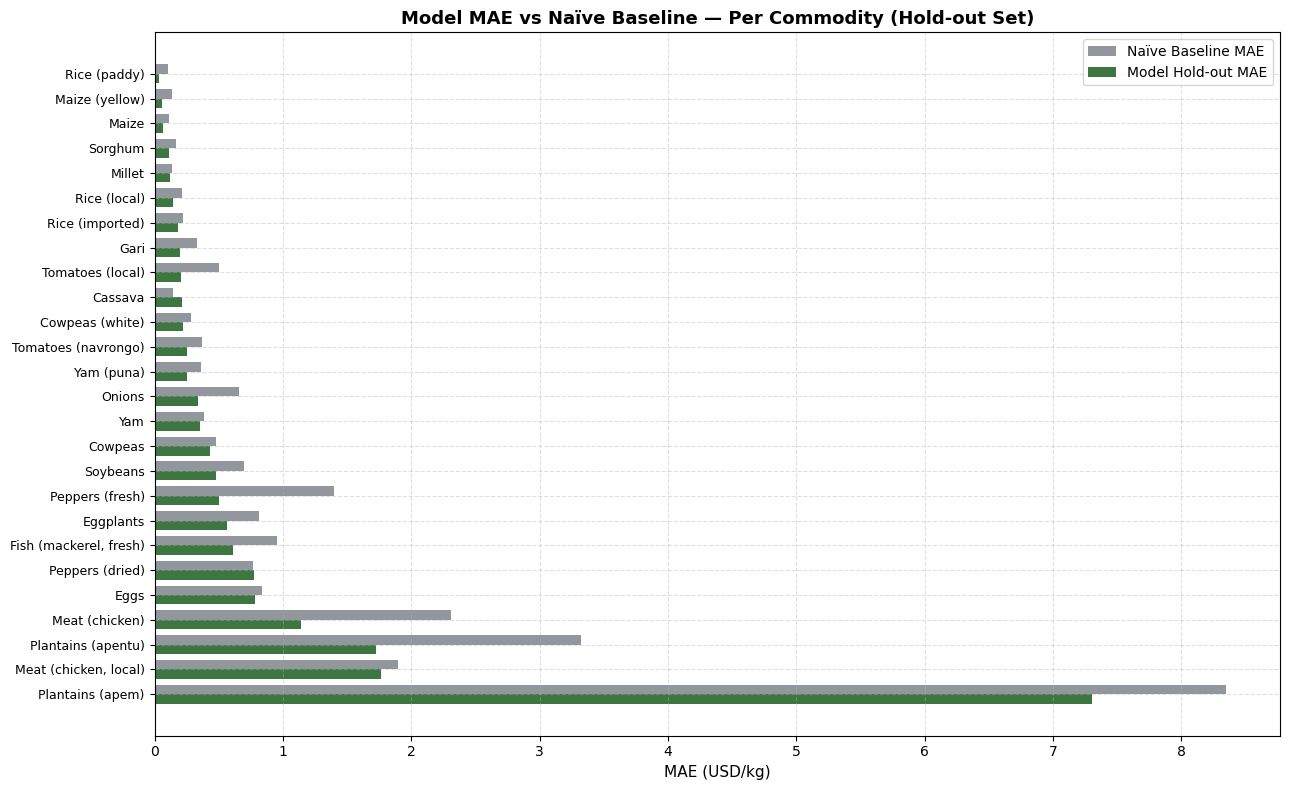

In [27]:
# ── Chart 1: Model MAE vs Baseline MAE for all commodities ───────────────────
plot_df = summary_df.sort_values('Holdout MAE', ascending=False)

fig, ax = plt.subplots(figsize=(13, 8))
y_pos = np.arange(len(plot_df))
bar_w = 0.38

ax.barh(y_pos + bar_w / 2, plot_df['Baseline MAE'], height=bar_w,
        label='Naïve Baseline MAE', color=PALETTE['gray'],   alpha=0.75)
ax.barh(y_pos - bar_w / 2, plot_df['Holdout MAE'],  height=bar_w,
        label='Model Hold-out MAE', color=PALETTE['green'], alpha=0.85)

ax.set_yticks(y_pos)
ax.set_yticklabels(plot_df['Commodity'], fontsize=9)
ax.set_xlabel('MAE (USD/kg)', fontsize=11)
ax.set_title('Model MAE vs Naïve Baseline — Per Commodity (Hold-out Set)',
             fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/results_mae_comparison.png', dpi=130, bbox_inches='tight')
plt.show()

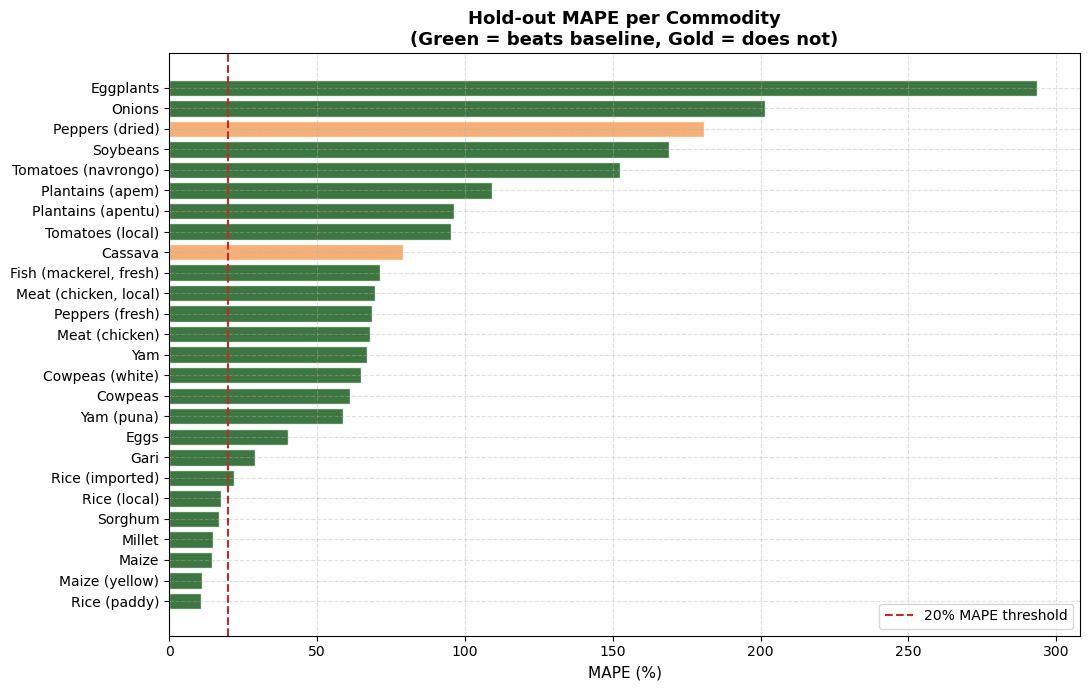

In [28]:
# ── Chart 2: MAPE per commodity ───────────────────────────────────────────────
plot_df2 = summary_df.sort_values('Holdout MAPE')

colors = [PALETTE['green'] if b == '✅ Yes' else PALETTE['gold']
          for b in plot_df2['Beats Baseline']]

fig, ax = plt.subplots(figsize=(11, 7))
ax.barh(plot_df2['Commodity'], plot_df2['Holdout MAPE'], color=colors, alpha=0.85, edgecolor='white')
ax.axvline(20, color=PALETTE['red'], linestyle='--', lw=1.5, label='20% MAPE threshold')
ax.set_xlabel('MAPE (%)', fontsize=11)
ax.set_title('Hold-out MAPE per Commodity\n(Green = beats baseline, Gold = does not)',
             fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/results_mape.png', dpi=130, bbox_inches='tight')
plt.show()

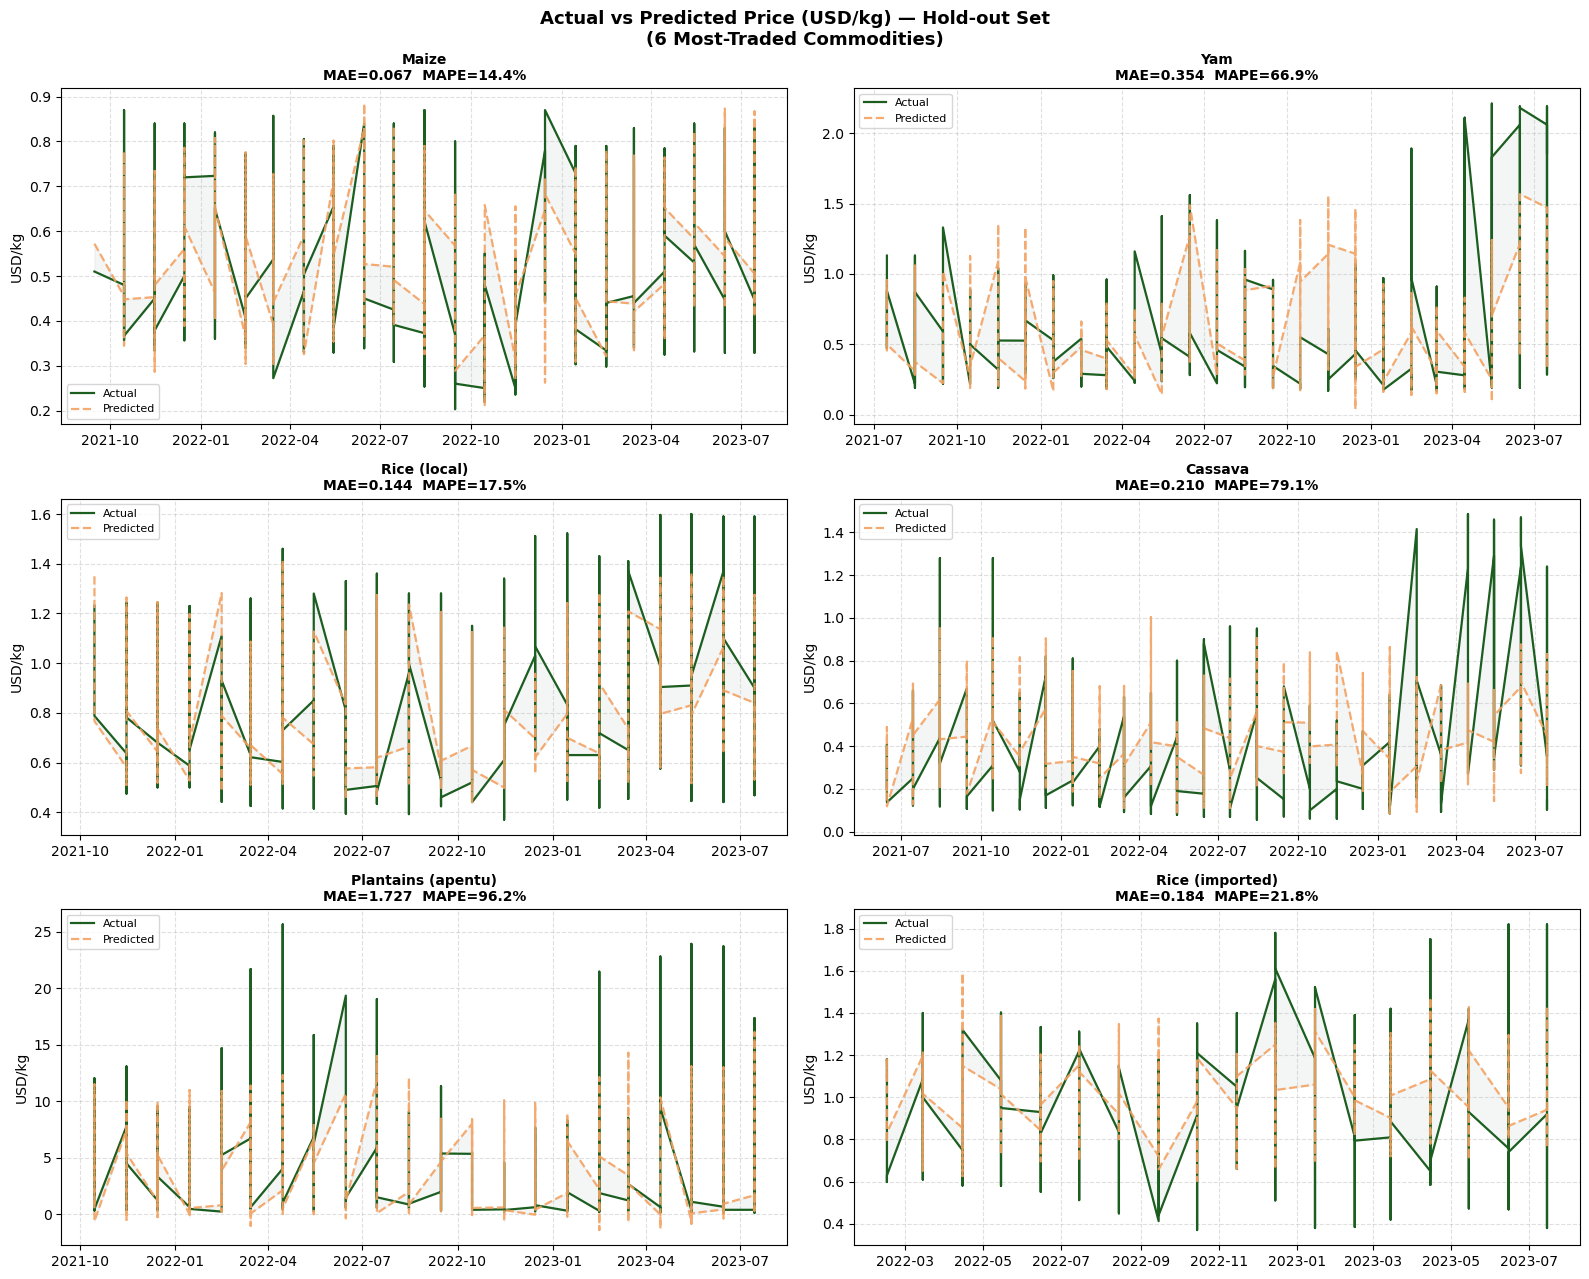

In [29]:
# ── Chart 3: Actual vs Predicted for the 6 most-traded commodities ────────────
top6 = (
    summary_df.sort_values('N Rows', ascending=False)
    .head(6)['Commodity'].tolist()
)

fig, axes = plt.subplots(3, 2, figsize=(16, 13))
axes = axes.flatten()
fig.suptitle('Actual vs Predicted Price (USD/kg) — Hold-out Set\n(6 Most-Traded Commodities)',
             fontsize=13, fontweight='bold')

for i, commodity in enumerate(top6):
    res  = results[commodity]
    pred = res['predictions']
    ax   = axes[i]

    ax.plot(pred['date'], pred['actual_usd_kg'],
            color=PALETTE['green'], lw=1.6, label='Actual')
    ax.plot(pred['date'], pred['predicted_usd_kg'],
            color=PALETTE['gold'],  lw=1.6, linestyle='--', label='Predicted', alpha=0.9)
    ax.fill_between(pred['date'],
                    pred['actual_usd_kg'], pred['predicted_usd_kg'],
                    alpha=0.07, color=PALETTE['gray'])

    mae  = res['holdout']['MAE']
    mape_ = res['holdout']['MAPE']
    ax.set_title(f'{commodity}\nMAE={mae:.3f}  MAPE={mape_:.1f}%', fontsize=10, fontweight='bold')
    ax.set_ylabel('USD/kg')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/results_actual_vs_predicted_top6.png', dpi=130, bbox_inches='tight')
plt.show()

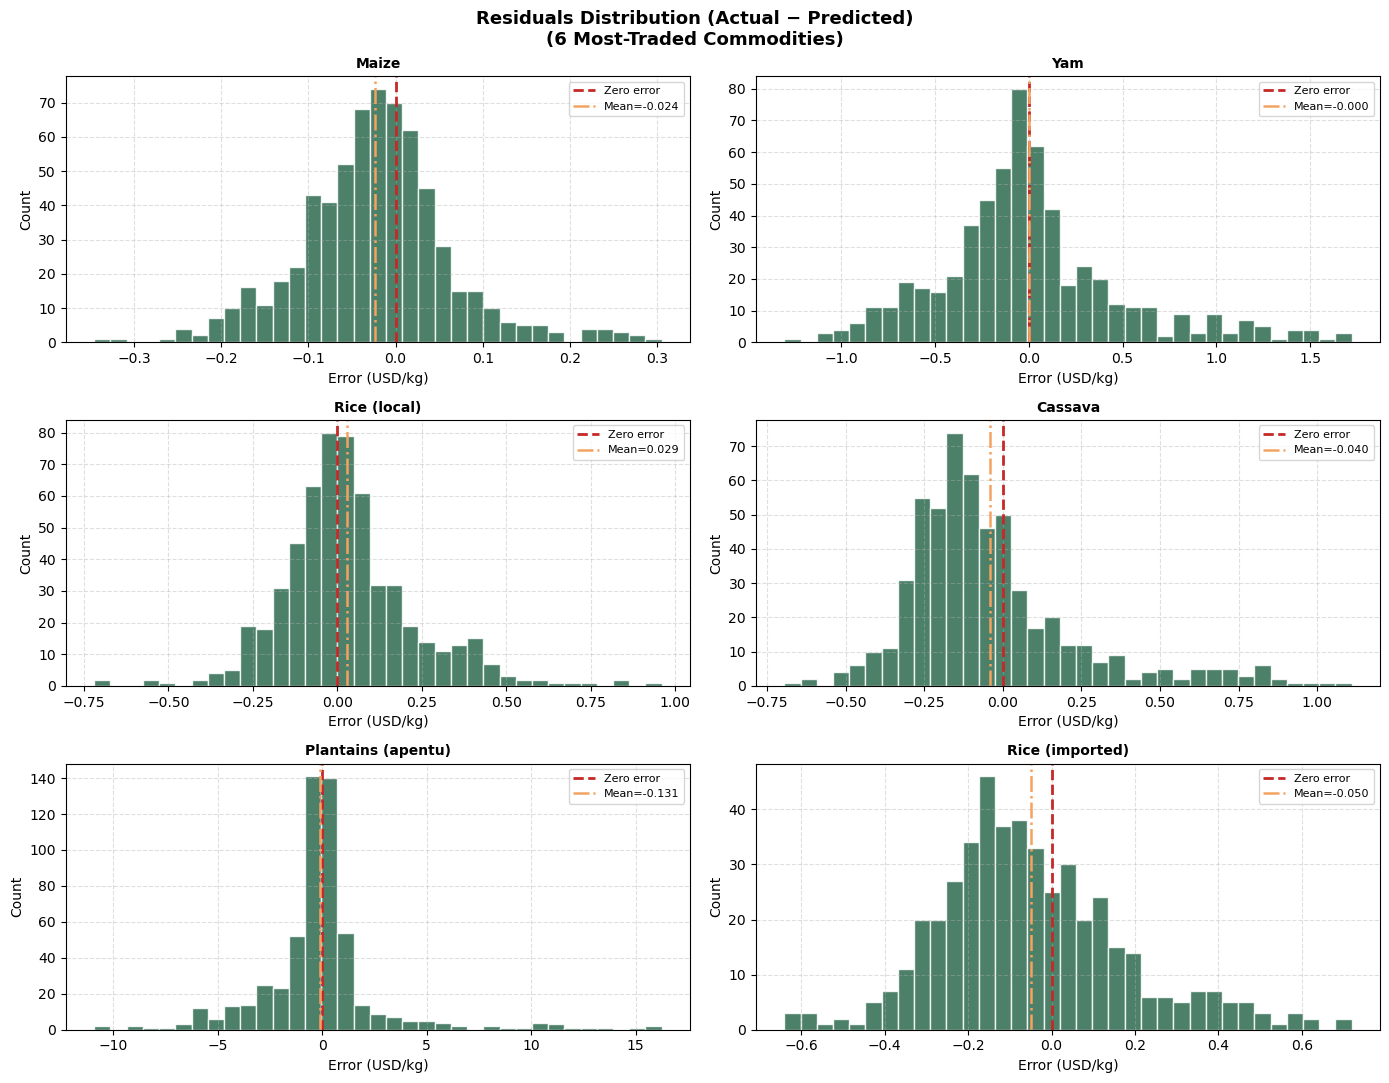

In [30]:
# ── Chart 4: Residuals distribution for the 6 most-traded commodities ─────────
fig, axes = plt.subplots(3, 2, figsize=(14, 11))
axes = axes.flatten()
fig.suptitle('Residuals Distribution (Actual − Predicted)\n(6 Most-Traded Commodities)',
             fontsize=13, fontweight='bold')

for i, commodity in enumerate(top6):
    pred = results[commodity]['predictions']
    errors = pred['error']
    ax = axes[i]

    ax.hist(errors, bins=35, color=PALETTE['mid_green'], edgecolor='white', alpha=0.85)
    ax.axvline(0,           color=PALETTE['red'],  lw=2.0, linestyle='--', label='Zero error')
    ax.axvline(errors.mean(), color=PALETTE['gold'], lw=1.8, linestyle='-.', label=f'Mean={errors.mean():.3f}')
    ax.set_title(commodity, fontweight='bold', fontsize=10)
    ax.set_xlabel('Error (USD/kg)')
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/results_residuals.png', dpi=130, bbox_inches='tight')
plt.show()

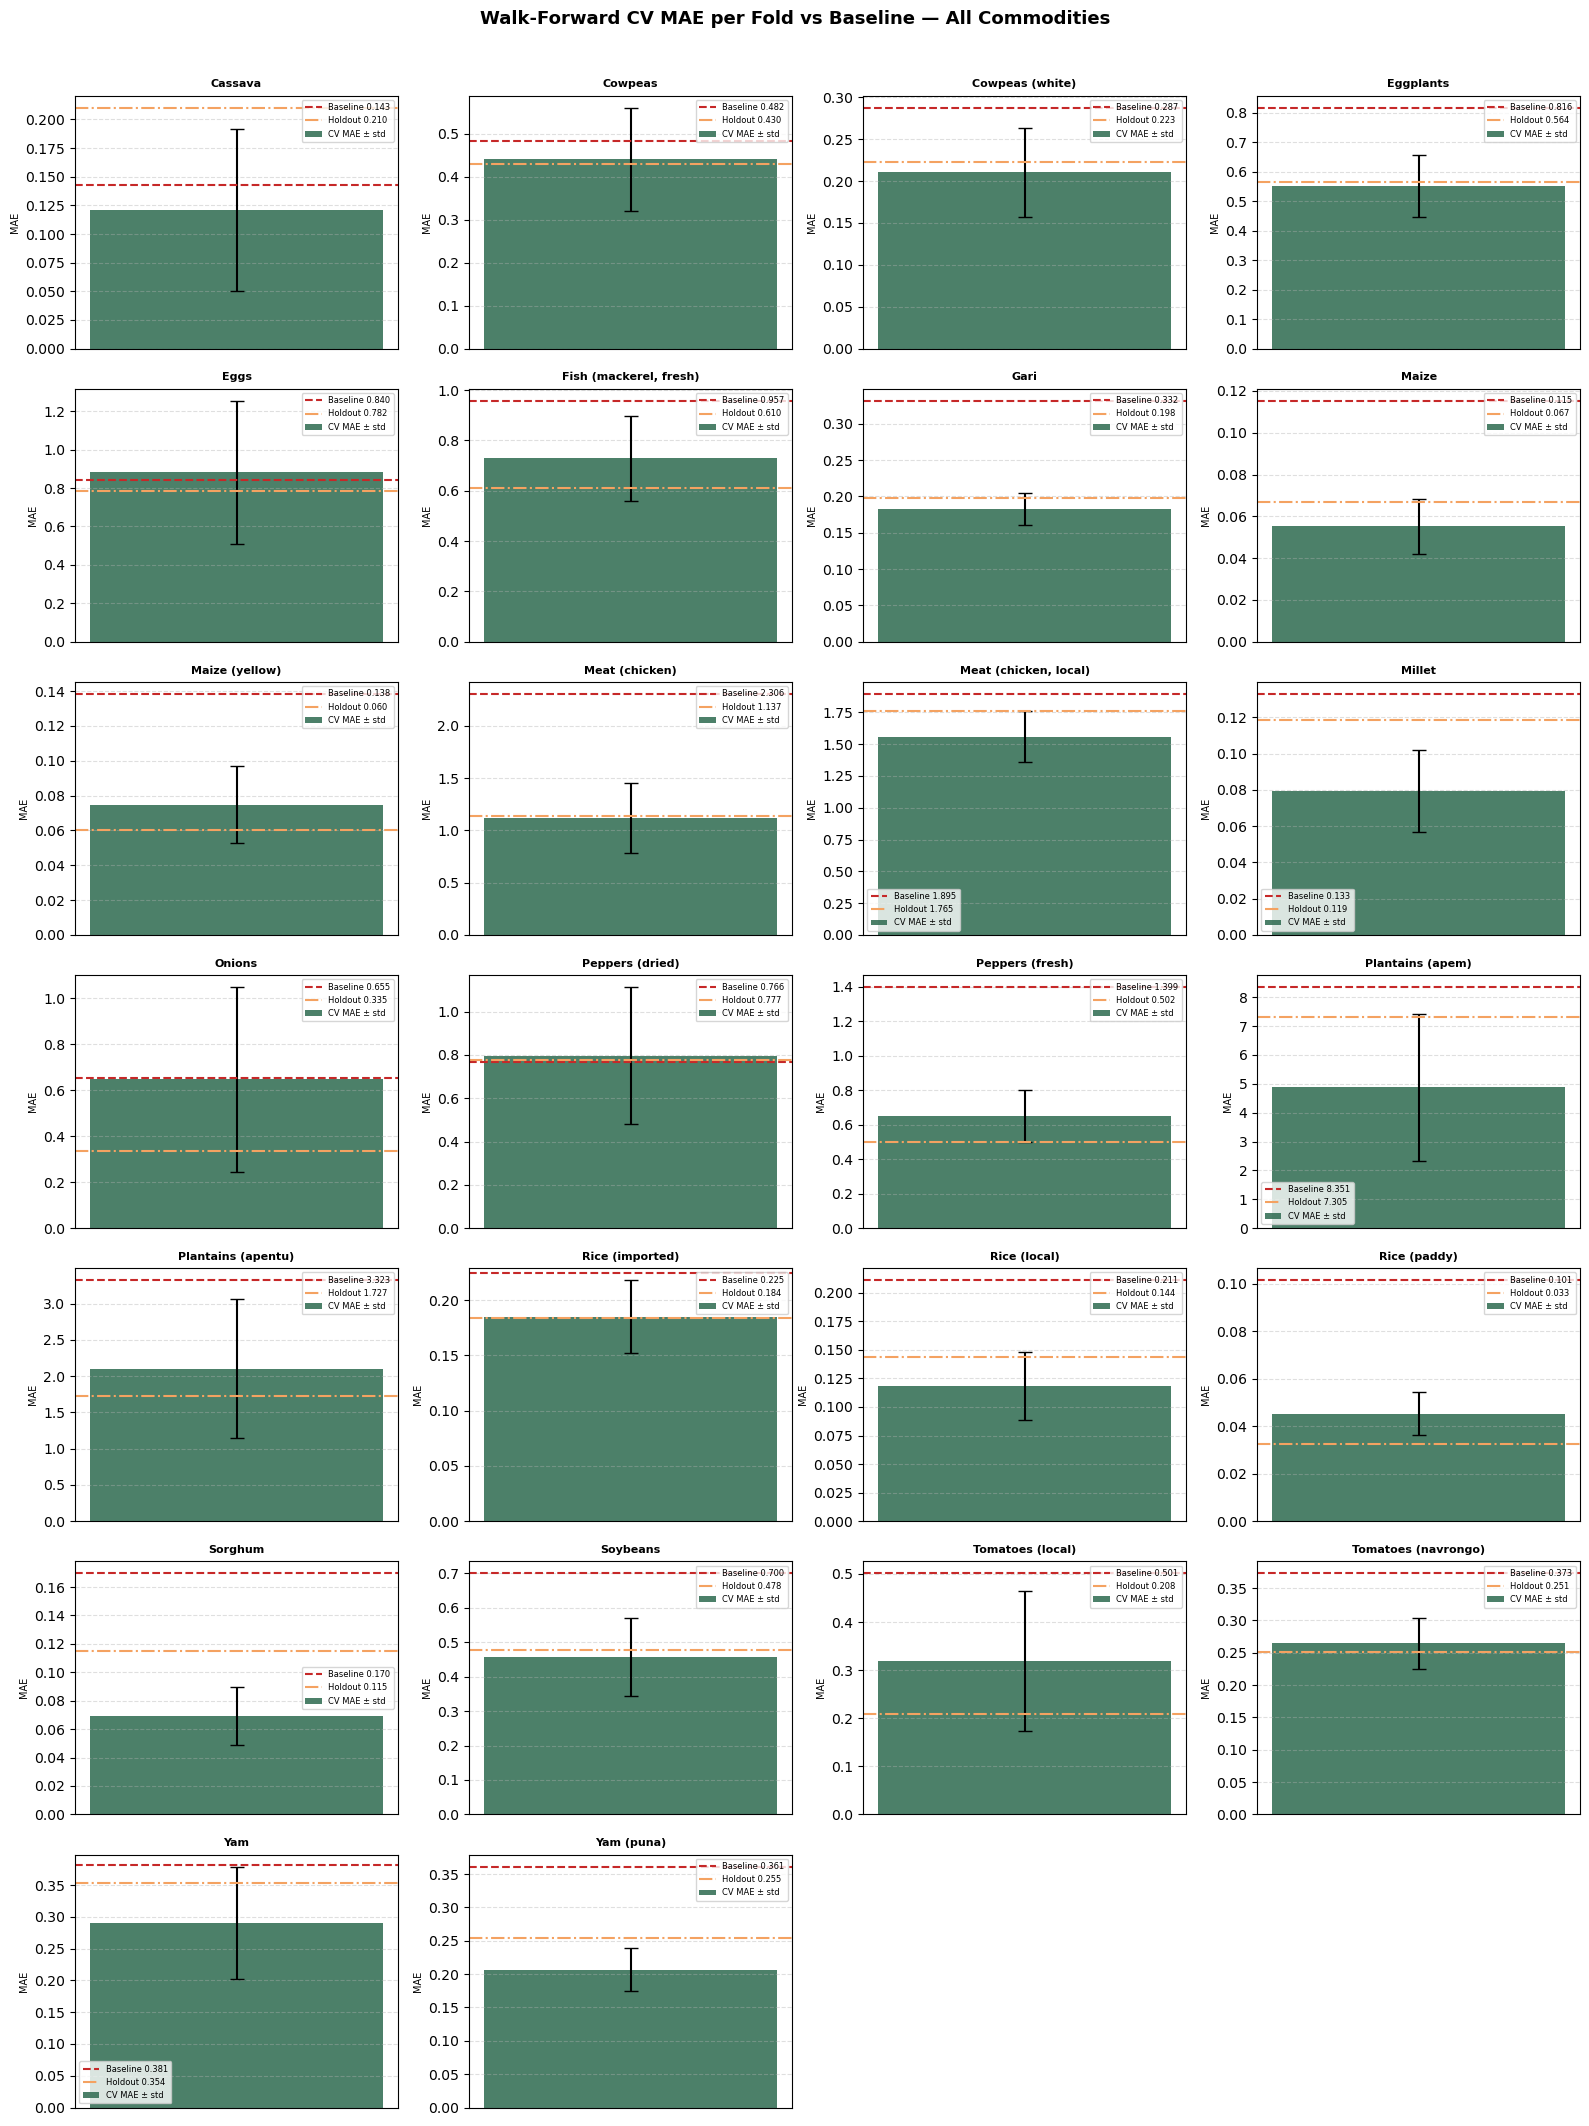

In [31]:
# ── Chart 5: CV fold performance for all commodities (MAE only) ───────────────
ok_results = {k: v for k, v in results.items() if v['status'] == 'ok'}
n = len(ok_results)
cols = 4
rows_grid = (n + cols - 1) // cols

fig, axes = plt.subplots(rows_grid, cols, figsize=(16, rows_grid * 3))
axes = axes.flatten()
fig.suptitle('Walk-Forward CV MAE per Fold vs Baseline — All Commodities',
             fontsize=13, fontweight='bold', y=1.01)

for i, (commodity, res) in enumerate(ok_results.items()):
    ax  = axes[i]
    maes = res['cv_mean']  # this is the mean; let's get fold-level from cv_metrics
    # We stored cv_mean/cv_std but not per-fold; show mean ± std as a bar + error bar
    ax.bar([1], [res['cv_mean']['MAE']], yerr=[res['cv_std']['MAE']],
           color=PALETTE['mid_green'], alpha=0.85, capsize=5, label='CV MAE ± std')
    ax.axhline(res['baseline']['MAE'], color=PALETTE['red'], linestyle='--', lw=1.5,
               label=f'Baseline {res["baseline"]["MAE"]:.3f}')
    ax.axhline(res['holdout']['MAE'],  color=PALETTE['gold'], linestyle='-.',  lw=1.5,
               label=f'Holdout {res["holdout"]["MAE"]:.3f}')
    ax.set_title(commodity, fontsize=8, fontweight='bold')
    ax.set_xticks([])
    ax.set_ylabel('MAE', fontsize=7)
    ax.legend(fontsize=6)

# Hide unused subplot panels
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/results_cv_all_commodities.png', dpi=130, bbox_inches='tight')
plt.show()

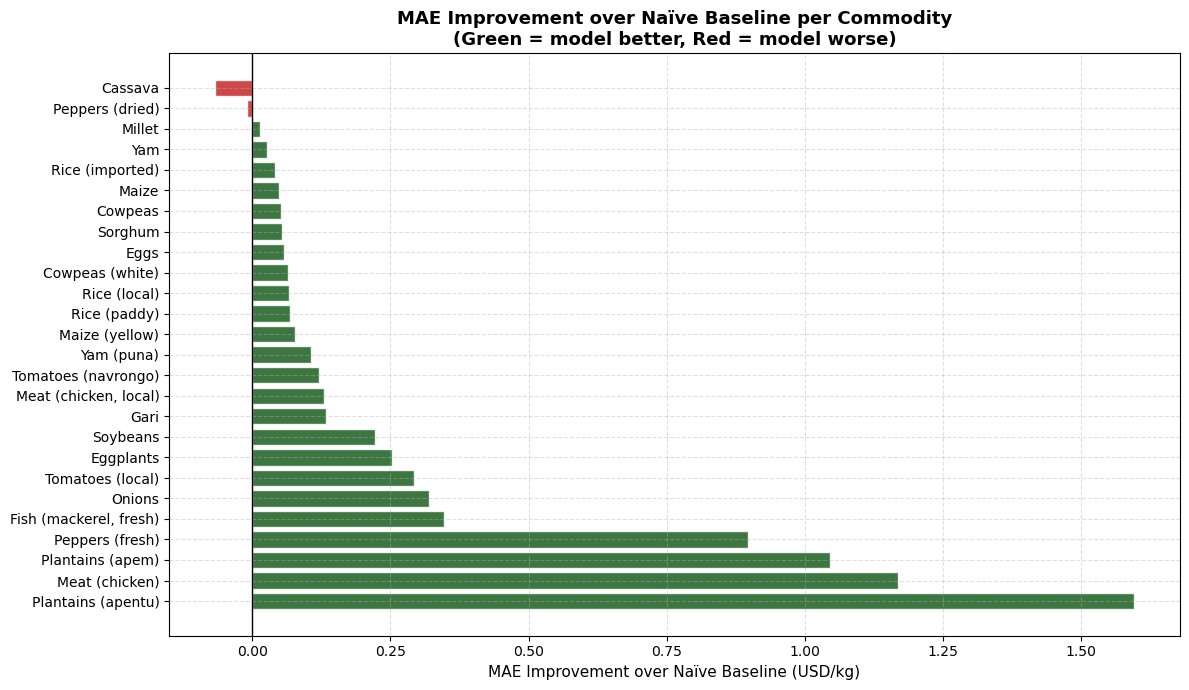

In [32]:
# ── Chart 6: MAE improvement over baseline ────────────────────────────────────
imp_df = summary_df.sort_values('MAE Improvement', ascending=False)
bar_colors = [PALETTE['green'] if v > 0 else PALETTE['red']
              for v in imp_df['MAE Improvement']]

fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(imp_df['Commodity'], imp_df['MAE Improvement'], color=bar_colors, alpha=0.85, edgecolor='white')
ax.axvline(0, color='black', lw=1)
ax.set_xlabel('MAE Improvement over Naïve Baseline (USD/kg)', fontsize=11)
ax.set_title('MAE Improvement over Naïve Baseline per Commodity\n'
             '(Green = model better, Red = model worse)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/results_mae_improvement.png', dpi=130, bbox_inches='tight')
plt.show()

---
## 9. Export Predictions

In [33]:
# ── Combine all commodity predictions into one CSV ────────────────────────────
combined_predictions = pd.concat(all_predictions, ignore_index=True)
combined_predictions = combined_predictions.sort_values(['commodity', 'date'])

output_path = f'{OUTPUT_DIR}/predictions_all_commodities.csv'
combined_predictions.to_csv(output_path, index=False)

print(f'✅ Predictions saved → {output_path}')
print(f'   Total rows:      {len(combined_predictions):,}')
print(f'   Commodities:     {combined_predictions["commodity"].nunique()}')
print(f'   Date range:      {combined_predictions["date"].min()} → {combined_predictions["date"].max()}')
print()
combined_predictions.head(10)

✅ Predictions saved → images//predictions_all_commodities.csv
   Total rows:      6,862
   Commodities:     26
   Date range:      2016-02-15 00:00:00 → 2023-07-15 00:00:00



,date,commodity,market,region,city,actual_usd_kg,predicted_usd_kg,error,abs_pct_error
0,2021-06-15,Cassava,KINTAMPO NORTH,BRONG AHAFO,Kintampo,0.2056,0.1879,0.0177,8.6281
1,2021-06-15,Cassava,KMA,ASHANTI,Kumasi,0.4071,0.4890,-0.0819,20.1143
2,2021-06-15,Cassava,TECHIMAN MUNICIPAL,BRONG AHAFO,Techiman,0.1369,0.1188,0.0181,13.2325
3,2021-07-15,Cassava,TEMA METROPOLIS,GREATER ACCRA,Tema,0.2500,0.5314,-0.2814,112.5597
4,2021-07-15,Cassava,TAMALE NORTH SUB METRO,NORTHERN,Tamale,0.3867,0.2967,0.0900,23.2624
5,2021-07-15,Cassava,TAMALE NORTH SUB METRO,NORTHERN,Tamale,0.4800,0.5123,-0.0323,6.7372
6,2021-07-15,Cassava,BOLGATANGA MUNICIPAL,UPPER EAST,Bolga,0.5196,0.4944,0.0251,4.8331
7,2021-07-15,Cassava,BOLGATANGA MUNICIPAL,UPPER EAST,Bolga,0.6600,0.6398,0.0202,3.0655
8,2021-07-15,Cassava,HOHOE MUNICIPAL,VOLTA,Hohoe,0.2700,0.3273,-0.0573,21.2278
9,2021-07-15,Cassava,HOHOE MUNICIPAL,VOLTA,Hohoe,0.2948,0.2810,0.0139,4.6996


In [34]:
# ── Save the results summary CSV ──────────────────────────────────────────────
summary_path = f'{OUTPUT_DIR}/model_performance_summary.csv'
summary_df.to_csv(summary_path, index=False)
print(f'✅ Summary saved → {summary_path}')

✅ Summary saved → images//model_performance_summary.csv


In [35]:
# ── Per-commodity prediction preview ─────────────────────────────────────────
print('Sample predictions per commodity (5 rows each):\n')
for commodity in all_commodities[:6]:  # show first 6 as a preview
    if results[commodity]['status'] == 'skipped':
        continue
    pred = results[commodity]['predictions']
    print(f'── {commodity} ──')
    print(pred[['date', 'region', 'actual_usd_kg', 'predicted_usd_kg', 'abs_pct_error']].head(5).to_string(index=False))
    print()

Sample predictions per commodity (5 rows each):

── Cassava ──
      date        region  actual_usd_kg  predicted_usd_kg  abs_pct_error
2021-06-15   BRONG AHAFO         0.2056            0.1879         8.6281
2021-06-15       ASHANTI         0.4071            0.4890        20.1143
2021-06-15   BRONG AHAFO         0.1369            0.1188        13.2325
2021-07-15 GREATER ACCRA         0.2500            0.5314       112.5597
2021-07-15      NORTHERN         0.3867            0.2967        23.2624

── Cowpeas ──
      date        region  actual_usd_kg  predicted_usd_kg  abs_pct_error
2022-11-15       ASHANTI         0.8800            1.5331        74.2130
2022-11-15       ASHANTI         0.8600            0.3872        54.9812
2022-11-15 GREATER ACCRA         0.9100            0.5788        36.3964
2022-12-15    UPPER EAST         1.7000            0.9542        43.8715
2022-12-15       WESTERN         1.6300            0.8720        46.5044

── Cowpeas (white) ──
      date      region 

In [36]:
# ── Final summary printout ────────────────────────────────────────────────────
ok = [r for r in results.values() if r['status'] == 'ok']
beat = [r for r in ok if r['beats_baseline']]

avg_holdout_mae  = np.mean([r['holdout']['MAE']  for r in ok])
avg_holdout_mape = np.mean([r['holdout']['MAPE'] for r in ok])
avg_baseline_mae = np.mean([r['baseline']['MAE'] for r in ok])

print('═' * 55)
print('  GHANA CROP PRICE PREDICTION — FINAL SUMMARY')
print('═' * 55)
print(f'  Commodities trained:        {len(ok)}')
print(f'  Beat naïve baseline:        {len(beat)} / {len(ok)}')
print()
print(f'  Avg baseline MAE:           {avg_baseline_mae:.4f} USD/kg')
print(f'  Avg model MAE (hold-out):   {avg_holdout_mae:.4f} USD/kg')
print(f'  Avg model MAPE (hold-out):  {avg_holdout_mape:.2f}%')
print(f'  Avg MAE improvement:        {avg_baseline_mae - avg_holdout_mae:.4f} USD/kg')
print()
print('  Best performers (lowest MAE):')
for _, row in summary_df.head(5).iterrows():
    print(f'    {row["Commodity"]:<28} MAE={row["Holdout MAE"]:.4f}')
print()
print('  Outputs saved:')
print(f'    predictions_all_commodities.csv')
print(f'    model_performance_summary.csv')
print('═' * 55)

═══════════════════════════════════════════════════════
  GHANA CROP PRICE PREDICTION — FINAL SUMMARY
═══════════════════════════════════════════════════════
  Commodities trained:        26
  Beat naïve baseline:        24 / 26

  Avg baseline MAE:           0.9985 USD/kg
  Avg model MAE (hold-out):   0.7243 USD/kg
  Avg model MAPE (hold-out):  80.09%
  Avg MAE improvement:        0.2742 USD/kg

  Best performers (lowest MAE):
    Rice (paddy)                 MAE=0.0327
    Maize (yellow)               MAE=0.0602
    Maize                        MAE=0.0670
    Sorghum                      MAE=0.1152
    Millet                       MAE=0.1187

  Outputs saved:
    predictions_all_commodities.csv
    model_performance_summary.csv
═══════════════════════════════════════════════════════
